In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# df = pd.read_csv("./student-por.csv") 
df = pd.read_csv("https://raw.githubusercontent.com/naimdotcom/ML-everything/main/Student-score-result/student-por.csv")

In [3]:
df.info

<bound method DataFrame.info of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... famrel fre

In [4]:
df.describe

<bound method NDFrame.describe of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... famrel f

In [5]:
df.head

<bound method NDFrame.head of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... famrel freet

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [7]:
x= df["absences"].values
y= df["G3"].values

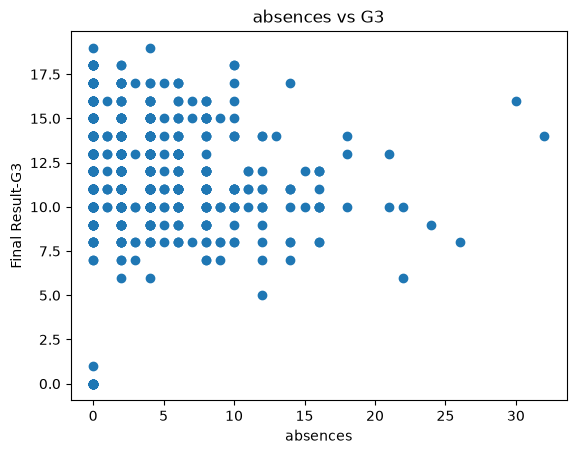

In [8]:
plt.scatter(x, y)
plt.xlabel("absences")
plt.ylabel("Final Result-G3")
plt.title("absences vs G3")
plt.show()

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y,test_size=0.33, random_state=42)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(434,) (434,) (215,) (215,)


In [10]:
x_train_mean = X_train.mean()
x_train_std = X_train.std()
y_train_mean = Y_train.mean()
y_train_std = Y_train.std()

x_train_norm = (X_train - x_train_mean) / x_train_std
y_train_norm = (Y_train - y_train_mean) / y_train_std
print("Train Norm:", x_train_norm.shape, y_train_norm.shape)

# 3. Normalize the test set USING TRAINING STATS (Fix applied here)
x_test_norm = (X_test - x_train_mean) / x_train_std
y_test_norm = (Y_test - y_train_mean) / y_train_std
print("Test Norm:", x_test_norm.shape, y_test_norm.shape)

Train Norm: (434,) (434,)
Test Norm: (215,) (215,)


In [11]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    f_wb = w*x+b
    cost = np.sum((f_wb - y)**2)/(2*m)
    return cost

In [12]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    f_wb = w*x+b
    dj_w = np.sum((f_wb - y)*x)/m
    dj_b = np.sum(f_wb -y)/m
    return dj_w, dj_b

In [13]:
def gradient_decent(x,y,alp = 0.001, iteration=1000):
    m = x.shape[0]
    w,b = 0,0
    cost_history = []
    for i in range(iteration):
        dj_w, dj_b=compute_gradient(x,y,w,b)
        w_tmp = w - alp*dj_w
        b_tmp = b - alp*dj_b
        cost_history.append(compute_cost(x,y,w_tmp,b_tmp))
        w,b=w_tmp, b_tmp
        
    return w,b,cost_history

In [14]:
W,B,cost_history = gradient_decent(x_train_norm, y_train_norm, 0.001, 10000)
print(W,B)
print(cost_history[0], cost_history[-1])
print(cost_history[-1] - cost_history[-10])

-0.06809088952607661 -1.392250370290709e-16
0.49999536553024865 0.4976816059320007
-8.598677325721837e-14


In [15]:
train_cost = compute_cost(x_train_norm, y_train_norm, W, B)
test_cost = compute_cost(x_test_norm, y_test_norm, W, B)
print(train_cost, test_cost)

0.4976816059320007 0.50815029177806


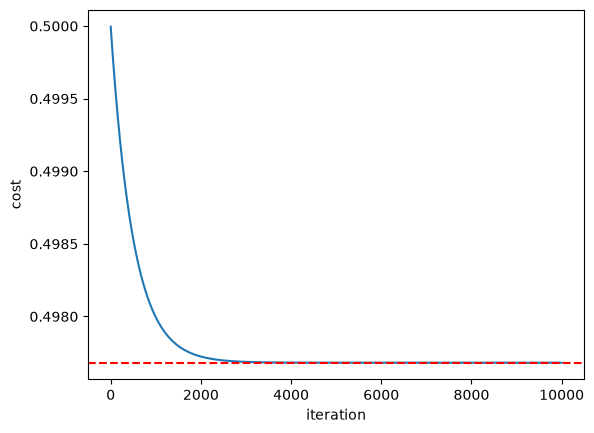

In [16]:
plt.plot(cost_history)
plt.axhline(y=cost_history[-1],color='red', linestyle='--', label=f'Final cost: {cost_history[-1]:.4f}')
plt.xlabel("iteration")
plt.ylabel("cost")
plt.show()

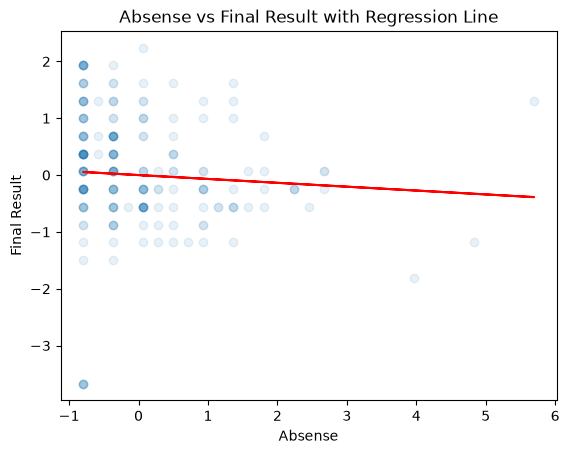

In [17]:
plt.scatter(x_test_norm, y_test_norm, alpha=0.1)
plt.plot(x_test_norm, W*x_test_norm + B, color='red')
plt.xlabel("Absense")
plt.ylabel("Final Result")
plt.title("Absense vs Final Result with Regression Line")
plt.show()

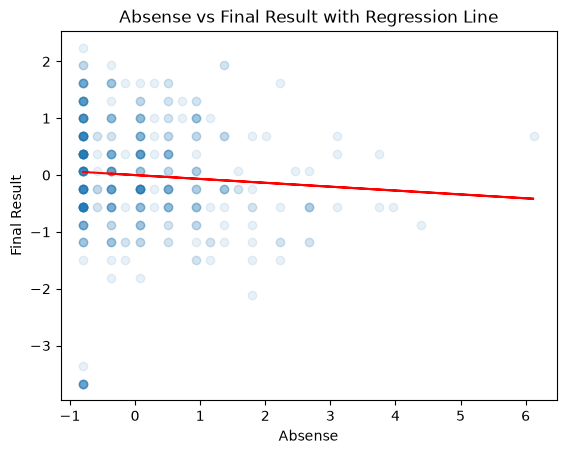

In [18]:
plt.scatter(x_train_norm, y_train_norm, alpha=0.1)
plt.plot(x_train_norm, W*x_train_norm + B, color='red')
plt.xlabel("Absense")
plt.ylabel("Final Result")
plt.title("Absense vs Final Result with Regression Line")
plt.show()

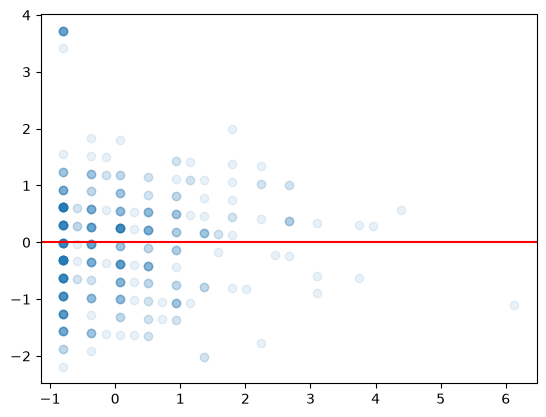

In [19]:
residuals = (W * x_train_norm + B) - y_train_norm
plt.scatter(x_train_norm, residuals, alpha=0.1)
plt.axhline(y=0, color='red')

(array([ 3.,  4.,  6., 14., 21., 11., 29., 40.,  2., 56., 24., 26., 63.,
        29., 36., 22., 11., 16.,  7.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  1., 10.]),
 array([-2.18700319, -1.98992721, -1.79285123, -1.59577525, -1.39869927,
        -1.20162329, -1.00454731, -0.80747133, -0.61039535, -0.41331937,
        -0.21624339, -0.01916741,  0.17790857,  0.37498454,  0.57206052,
         0.7691365 ,  0.96621248,  1.16328846,  1.36036444,  1.55744042,
         1.7545164 ,  1.95159238,  2.14866836,  2.34574434,  2.54282032,
         2.7398963 ,  2.93697228,  3.13404826,  3.33112424,  3.52820022,
         3.7252762 ]),
 <BarContainer object of 30 artists>)

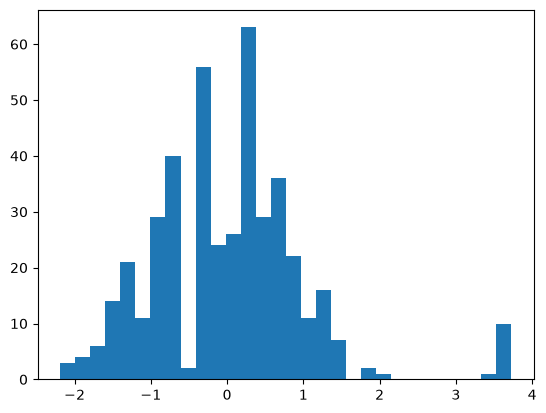

In [20]:
plt.hist(residuals, bins=30)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_norm.reshape(-1,1),y_train_norm)
print(model.coef_, model.intercept_)

[-0.06809397] -1.546018852610027e-16
